In [19]:
from __future__ import print_function, unicode_literals, absolute_import, division
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams["image.interpolation"] = None
import matplotlib.pyplot as plt

import torch
from glob import glob
from tqdm import tqdm
from tifffile import imread
from csbdeep.utils import Path, normalize

from stardist import fill_label_holes, random_label_cmap, calculate_extents, gputools_available
from stardist.matching import matching, matching_dataset
from stardist.models import Config2D, StarDist2D, StarDistData2D
import pandas as pd
from csbdeep.data import PercentileNormalizer
from stardist.utils import mask_to_categorical
from stardist.plot import render_label
from typing import Optional
import polars as pl
from towbintools.deep_learning.deep_learning_tools import (
    load_segmentation_model_from_checkpoint,
)
from towbintools.deep_learning.utils.augmentation import (
    get_prediction_augmentation_from_model,
)
plt.rcParams["figure.figsize"] = (15,15)
lbl_cmap = random_label_cmap()

np.random.seed(0)
lbl_cmap = random_label_cmap()
lbl_cmap_classes = matplotlib.cm.tab20

def plot_img_label(img, lbl, cls_dict, n_classes=2, img_title="image", lbl_title="label", cls_title="classes", **kwargs):
    c = mask_to_categorical(lbl, n_classes=n_classes, classes=cls_dict)
    res = np.zeros(lbl.shape, np.uint16)
    for i in range(1,c.shape[-1]):
        m = c[...,i]>0
        res[m] = i
    class_img = lbl_cmap_classes(res)
    class_img[...,:3][res==0] = 0 
    class_img[...,-1][res==0] = 1
    
    fig, (ai,al,ac) = plt.subplots(1,3, figsize=(25,15), gridspec_kw=dict(width_ratios=(1.,1,1)))
    im = ai.imshow(img, cmap='gray')
    ai.set_title(img_title)    
    al.imshow(render_label(lbl, .8*normalize(img, clip=True), normalize_img=False, alpha_boundary=.8,cmap=lbl_cmap))
    al.set_title(lbl_title)
    ac.imshow(class_img)
    ac.imshow(render_label(res, .8*normalize(img, clip=True), normalize_img=False, alpha_boundary=.8, cmap=lbl_cmap_classes))
    ac.set_title(cls_title)
    plt.tight_layout()    
    for a in ai,al,ac:
        a.axis("off")
    return ai,al,ac

def read_tiff_file(
    file_path: str,
    channels_to_keep: Optional[list[int]] = None,
) -> np.ndarray:
    """
    Read a TIFF file and optionally select specific channels from the image.

    Parameters:
            file_path (str): Path to the TIFF image file.
            channels_to_keep (list): List of channel indices to keep. If empty or None, all channels are kept.

    Returns:
            np.ndarray: The image data as a NumPy array. The number of dimensions may vary depending on the input and selected channels.

    Raises:
            ValueError: If the image file cannot be read.
    """
    try:
        image = imread(file_path)
    except Exception as e:
        raise ValueError(f"Error while reading image file {file_path} : {e}")

    # If no channels are specified, return the image as is.
    if image.ndim == 2 or not channels_to_keep:
        return image

    if image.ndim == 3:
        return image[channels_to_keep, ...].squeeze()  # type: ignore
    else:
        return image[:, channels_to_keep, ...].squeeze()  # type: ignore

def class_from_res(res):
    cls_dict = dict((i+1,c) for i,c in enumerate(res['class_id']))
    return cls_dict

In [55]:
demo_model = False

if demo_model:
    print (
        "NOTE: This is loading a previously trained demo model!/n"
        "      Please set the variable 'demo_model = False' to load your own trained model.",
        file=sys.stderr, flush=True
    )
    model = StarDist2D.from_pretrained('2D_demo')
else:
    model = StarDist2D(None, name='newest_panoptic_emr1_60x', basedir='/mnt/towbin.data/shared/spsalmon/towbinlab_segmentation_database/models/stardist/')
None

classification_model_path = "/mnt/towbin.data/shared/spsalmon/stardist_database/60x_emr1_col10GFP_classification_dataset/model/nuclear_classification_unet_b0/best_light.ckpt"
classification_model = load_segmentation_model_from_checkpoint(classification_model_path)
classification_model.eval()
classification_augmentation = get_prediction_augmentation_from_model(classification_model)

# print(classification_augmentation)
test_stack_path = "/mnt/towbin.data/shared/spsalmon/20251023_115945_091_ZIVA_60x_397_405_yap_dynamics/raw_zstack/Time00051_Point0033_ChannelDIA,DIA_Seq4146.ome.tiff"
stack = read_tiff_file(test_stack_path, channels_to_keep=[1])
normalizer = PercentileNormalizer(1, 99.8, do_after=False)

mask = np.zeros(stack.shape, dtype=np.uint16)
class_df = pl.DataFrame(schema={"Plane": pl.Int64, "Label": pl.Int64, "Class": pl.Int64})
classes_list = []
class_probabilities_list = []
for i, plane in tqdm(enumerate(stack), total=stack.shape[0], desc="Predicting planes"):
    with torch.no_grad():
        normalized_plane = classification_augmentation(image=plane)['image']
        normalized_plane = torch.from_numpy(normalized_plane).float()
        classes_probabilities = classification_model(normalized_plane[None, None,...]).cpu().numpy().squeeze()[1:]
        # for c in range(classes_probabilities.shape[0]):
        #     # plot histogram of probabilities
        #     plt.hist(classes_probabilities[c].ravel(), bins=50)
        #     plt.title(f'Class {c} probabilities histogram')
        #     plt.show()
        #     plt.imshow(classes_probabilities[c], cmap='gray')
        #     plt.title(f'Class {c} probabilities')
        #     plt.show()

        class_probabilities_list.append(classes_probabilities)

        # labels, details = model.predict_instances(plane, prob_thresh=None, normalizer=normalizer)

        # # for each label, get the predicted class from the classification model
        # classes = {}        
        # for label in np.unique(labels):
        #     if label == 0:
        #         continue
        #     probabilities_for_label = np.sum(classes_probabilities*(labels==label), axis=(1,2))
            
        #     # print(probabilities_for_label)
        #     predicted_class = np.argmax(probabilities_for_label) + 1
        #     classes[label] = predicted_class

        # # print(classes)

        # plot_img_label(normalized_plane.cpu().numpy(), labels, classes, img_title=f'Plane {i} - Image', lbl_title=f'Plane {i} - Labels', cls_title=f'Plane {i} - Classes')

        # # print(classes)

        # mask[i] = labels
        # classes = class_from_res(details)
        # classes_list.append(classes)
        # # print(f'Plane {i}: {len(classes)} objects detected.')
        # # print(classes)
        # if classes:
        #     plane_df = pl.DataFrame(
        #         {
        #             "Plane": [i] * len(classes),
        #             "Label": list(classes.keys()),
        #             "Class": list(classes.values()),
        #         }
        #     ).with_columns(
        #         [
        #             pl.col("Plane").cast(pl.Int64),
        #             pl.col("Label").cast(pl.Int64),
        #             pl.col("Class").cast(pl.Int64),
        #         ]
        #     )
        #     class_df = pl.concat([class_df, plane_df], how="vertical")
        


Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.45618, nms_thresh=0.3.


Predicting planes: 100%|██████████| 25/25 [00:46<00:00,  1.88s/it]


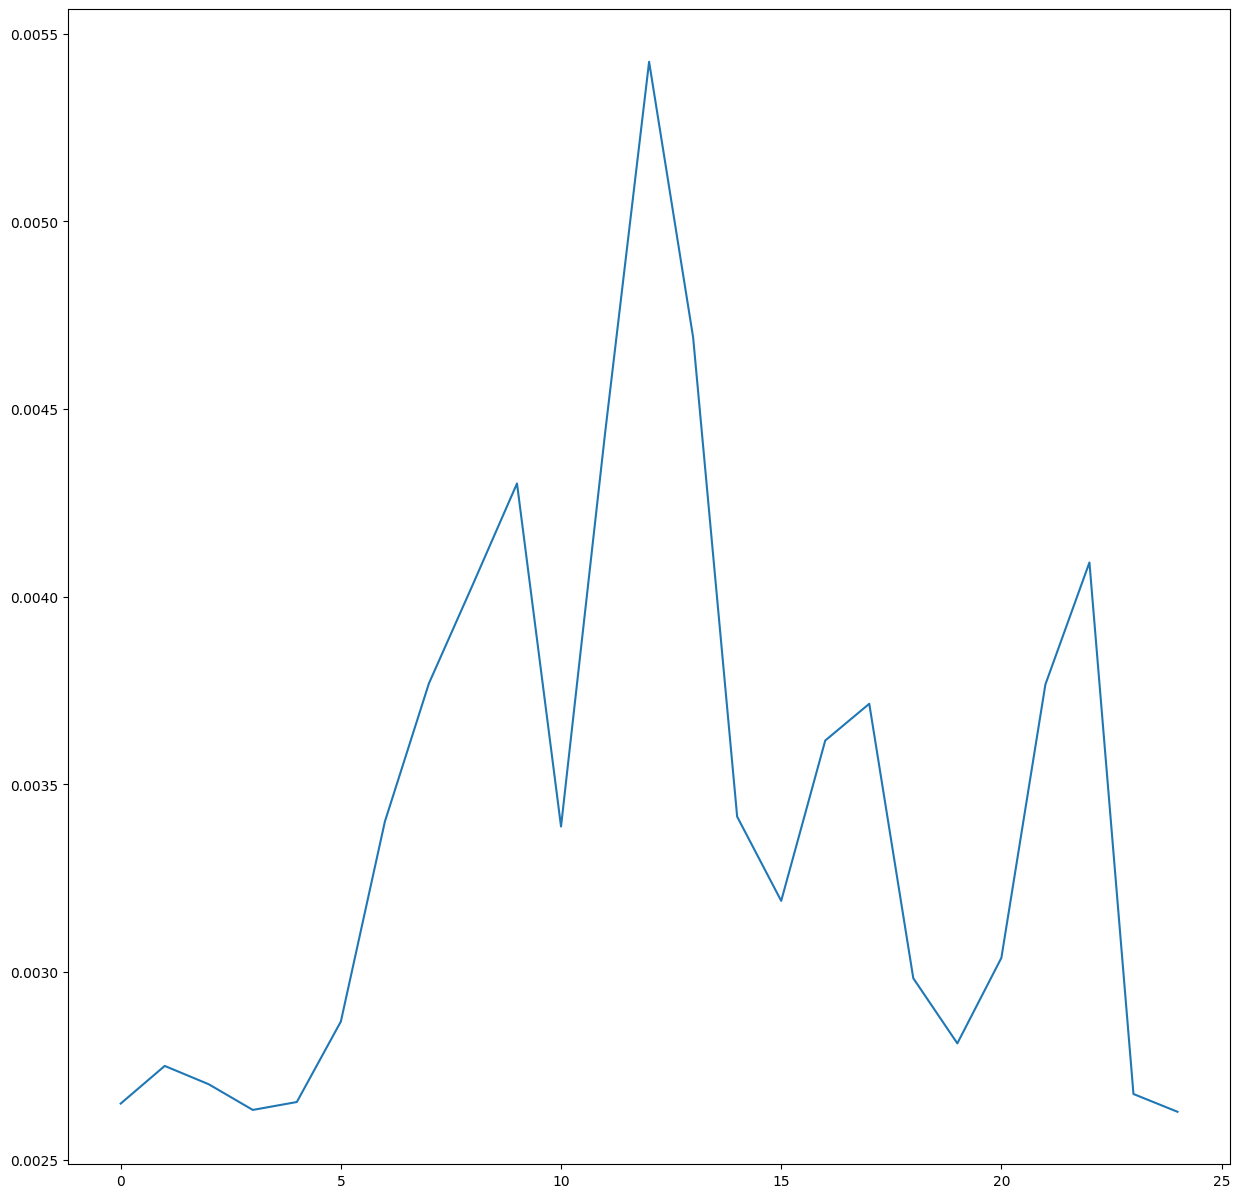

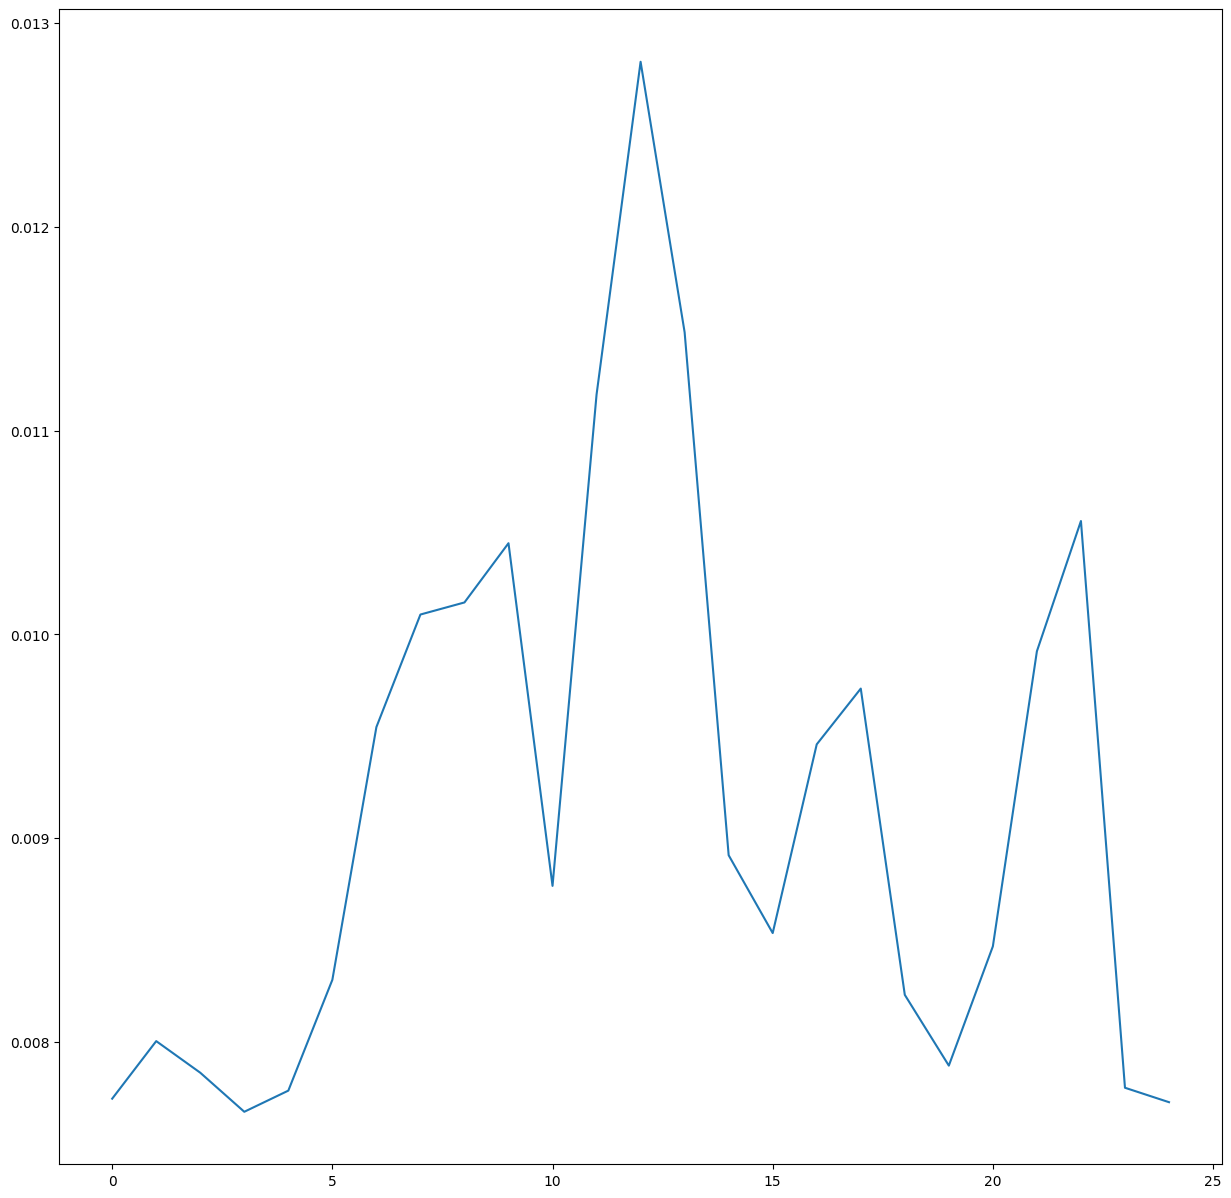

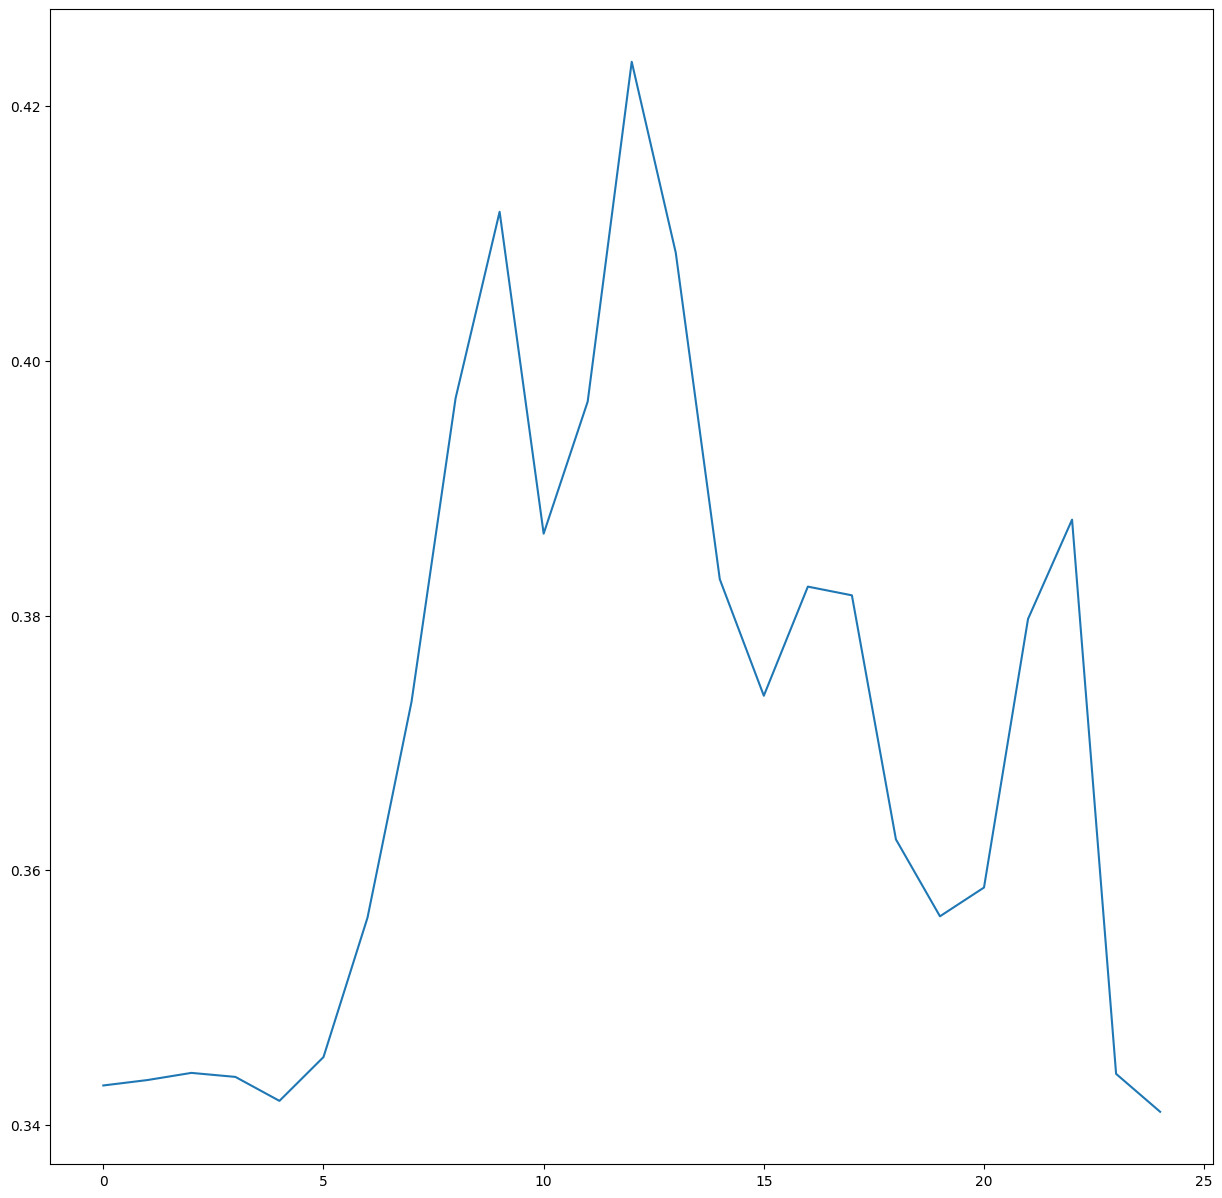

Max ratio at plane 12 with ratio 0.42348140478134155


In [56]:
epidermis_means = []
other_means = []
ratio_means = []
diff_means = []
for p in class_probabilities_list:
    mean_epidermis = p[0].mean()
    mean_other = p[1].mean()
    ratio = mean_epidermis / (mean_other + 1e-6)  # add small value to avoid division by zero
    epidermis_means.append(mean_epidermis)
    other_means.append(mean_other)
    ratio_means.append(ratio)

plt.plot(epidermis_means, label='Epidermis Mean Probability')
plt.show()
plt.plot(other_means, label='Other Mean Probability')
plt.show()
plt.plot(ratio_means, label='Epidermis/Other Mean Probability Ratio')
plt.show()

print(f'Max ratio at plane {np.argmax(ratio_means)} with ratio {np.max(ratio_means)}')

In [57]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

def zstack_viewer(img, labels, classes,
                  n_classes=3,
                  img_title="image", lbl_title="label", cls_title="classes",
                  axis=0):
    zmax = img.shape[axis] - 1

    slider = widgets.IntSlider(
        min=0, max=zmax, step=1, value=0,
        description="z",
        continuous_update=False
    )

    out = widgets.Output()

    def get_slice(arr, z):
        slc = [slice(None)] * arr.ndim
        slc[axis] = z
        return arr[tuple(slc)]

    def render(z):
        with out:
            clear_output(wait=True)

            # Important: close any existing matplotlib figures created previously
            plt.close("all")

            img_z = get_slice(img, z)
            lbl_z = get_slice(labels, z)

            plot_img_label(
                img_z, lbl_z, classes[z],
                n_classes=n_classes,
                img_title=f"{img_title} (z={z})",
                lbl_title=f"{lbl_title} (z={z})",
                cls_title=cls_title
            )

            # If plot_img_label doesn't call plt.show(), force it:
            plt.show()

    def on_change(change):
        if change["name"] == "value":
            render(change["new"])

    slider.observe(on_change, names="value")

    # initial draw
    with out:
        render(slider.value)

    display(slider, out)
    return slider, out

zstack_viewer(stack, mask, classes_list, n_classes=3, img_title="DIA channel", lbl_title="Predicted labels", cls_title="Predicted classes")

IntSlider(value=0, continuous_update=False, description='z', max=24)

Output()

(IntSlider(value=0, continuous_update=False, description='z', max=24),
 Output())